# 02 - Comparare Detectoare: A22 -> A3 -> A3-retrain -> A4

Evolutia detectorului de-a lungul tuturor experimentelor.
**Cross-evaluation**: toate modelele evaluate pe ACELASI test set (parks_detect_A4).

| Experiment | Model | Dataset | mAP50 | Delta |
|------------|-------|---------|-------|---------|
| A22 | YOLOv8n | Parks 34 img | 0.393 | baseline |
| A3-final | YOLOv8s | Parks full 1544 img | 0.443 | +5.0pp |
| A3-retrain | YOLOv8s | Parks resized 1544 img | 0.482 | +3.9pp |
| **A4** | **YOLOv8s** | **Parks+TACO 2307 img** | **0.6607** | **+18.4pp** |

In [1]:
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
REPO_ROOT = Path('../..').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
from ultralytics import YOLO
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'font.size':11,
    'axes.titlesize':12,'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3})
COLORS = plt.cm.Blues(np.linspace(0.35, 0.95, 4))
A4_DIR  = REPO_ROOT / 'runs' / 'detect' / 'parks-trash-A4-8010'
A3R_DIR = REPO_ROOT / 'runs' / 'detect' / 'parks-trash-A3-retrain'
DATA_A4 = str(REPO_ROOT / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')
print('A4 weights: ', (A4_DIR/'weights'/'best.pt').exists())
print('A3R weights:', (A3R_DIR/'weights'/'best.pt').exists())


A4 weights:  False
A3R weights: True


---
## 1 - Tabel comparativ (date din experimentele inregistrate)


In [2]:
data = {
    'Experiment': ['A22 (baseline)','A3-final','A3-retrain','A4 (best)'],
    'Model':      ['YOLOv8n','YOLOv8s','YOLOv8s','YOLOv8s'],
    'Params(M)':  [3.2, 11.2, 11.2, 11.2],
    'Dataset':    ['Parks 34img','Parks 1544img','Parks resized 1544img','Parks+TACO 2307img'],
    'Epochs':     [150, 150, 150, 50],
    'imgsz':      [416, 640, 640, 640],
    'Precision':  [0.707, 0.623, 0.628, 0.857],
    'Recall':     [0.286, 0.406, 0.437, 0.552],
    'mAP50':      [0.393, 0.443, 0.482, 0.6607],
    'mAP50-95':   [0.281, 0.321, 0.356, 0.523],
    'F1':         [round(2*0.707*0.286/(0.707+0.286),3),
                   round(2*0.623*0.406/(0.623+0.406),3),
                   round(2*0.628*0.437/(0.628+0.437),3),
                   round(2*0.857*0.552/(0.857+0.552),3)],
}
df = pd.DataFrame(data).set_index('Experiment')
display(df.style
    .highlight_max(subset=['Precision','Recall','mAP50','mAP50-95','F1'],color='#90EE90')
    .highlight_min(subset=['mAP50'],color='#FFB6B6')
    .format({'Precision':'{:.3f}','Recall':'{:.3f}','mAP50':'{:.3f}',
             'mAP50-95':'{:.3f}','F1':'{:.3f}','Params(M)':'{:.1f}'}))


,Model,Params(M),Dataset,Epochs,imgsz,Precision,Recall,mAP50,mAP50-95,F1
Experiment,,,,,,,,,,
A22 (baseline),YOLOv8n,3.2,Parks 34img,150,416,0.707,0.286,0.393,0.281,0.407
A3-final,YOLOv8s,11.2,Parks 1544img,150,640,0.623,0.406,0.443,0.321,0.492
A3-retrain,YOLOv8s,11.2,Parks resized 1544img,150,640,0.628,0.437,0.482,0.356,0.515
A4 (best),YOLOv8s,11.2,Parks+TACO 2307img,50,640,0.857,0.552,0.661,0.523,0.671


---
## 2 - Grafic evolutie mAP50 (bara + delta)


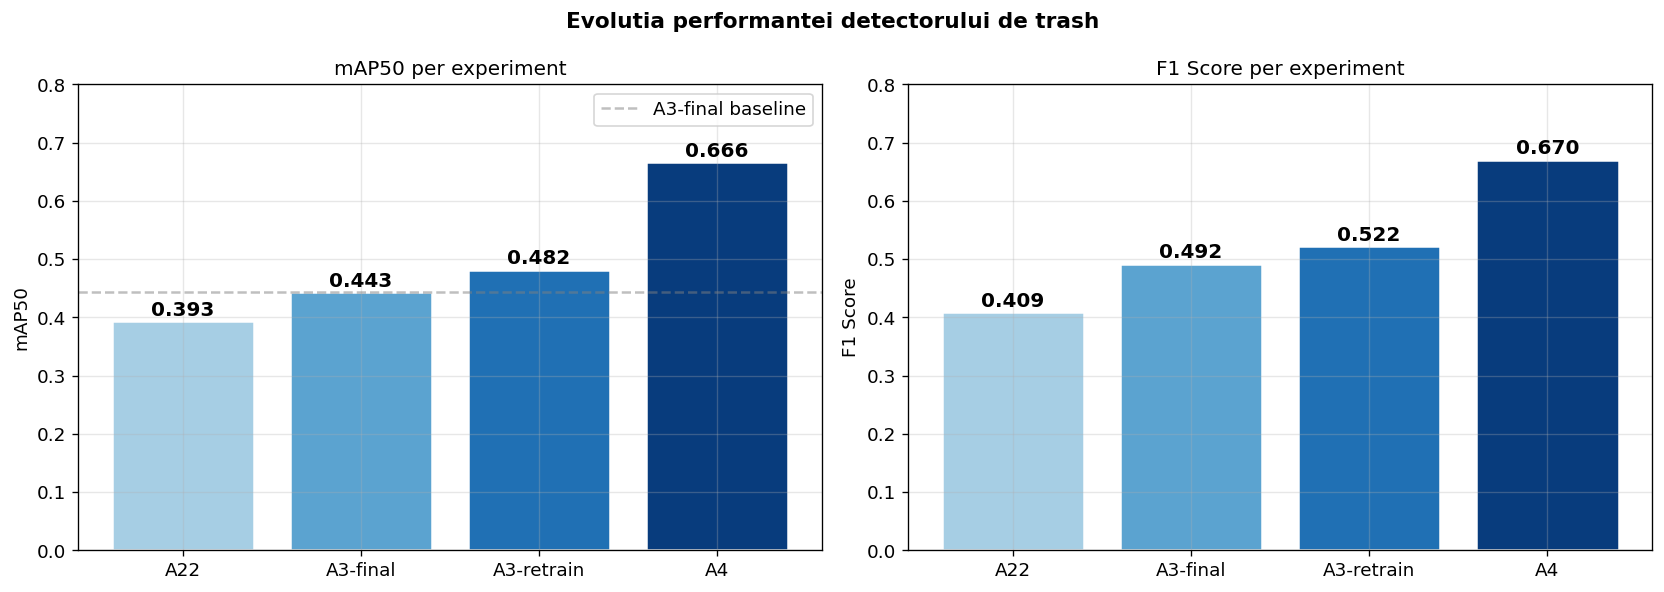

Salvat: D:\TrashDetectionSystem\runs\detector_comparison.png


In [3]:
experiments = ['A22','A3-final','A3-retrain','A4']
map50_vals  = [0.393, 0.443, 0.482, 0.666]
f1_vals     = [0.409, 0.492, 0.522, 0.670]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
# mAP50 bars
bars=ax1.bar(experiments,map50_vals,color=COLORS,edgecolor='white',lw=1.5)
ax1.set_ylabel('mAP50'); ax1.set_title('mAP50 per experiment'); ax1.set_ylim(0,0.80)
ax1.axhline(0.443,color='gray',ls='--',alpha=0.5,label='A3-final baseline')
ax1.legend()
for bar,val in zip(bars,map50_vals):
    ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
             f'{val:.3f}',ha='center',fontsize=12,fontweight='bold')
ax1.grid(axis='y',alpha=0.3)
# F1 bars
bars2=ax2.bar(experiments,f1_vals,color=COLORS,edgecolor='white',lw=1.5)
ax2.set_ylabel('F1 Score'); ax2.set_title('F1 Score per experiment'); ax2.set_ylim(0,0.80)
for bar,val in zip(bars2,f1_vals):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
             f'{val:.3f}',ha='center',fontsize=12,fontweight='bold')
ax2.grid(axis='y',alpha=0.3)
plt.suptitle('Evolutia performantei detectorului de trash',fontsize=13,fontweight='bold')
plt.tight_layout()
out=REPO_ROOT/'runs'/'detector_comparison.png'
plt.savefig(str(out),dpi=150,bbox_inches='tight')
plt.show(); print(f'Salvat: {out}')


---
## 3 - Curbe training: A3-retrain vs A4


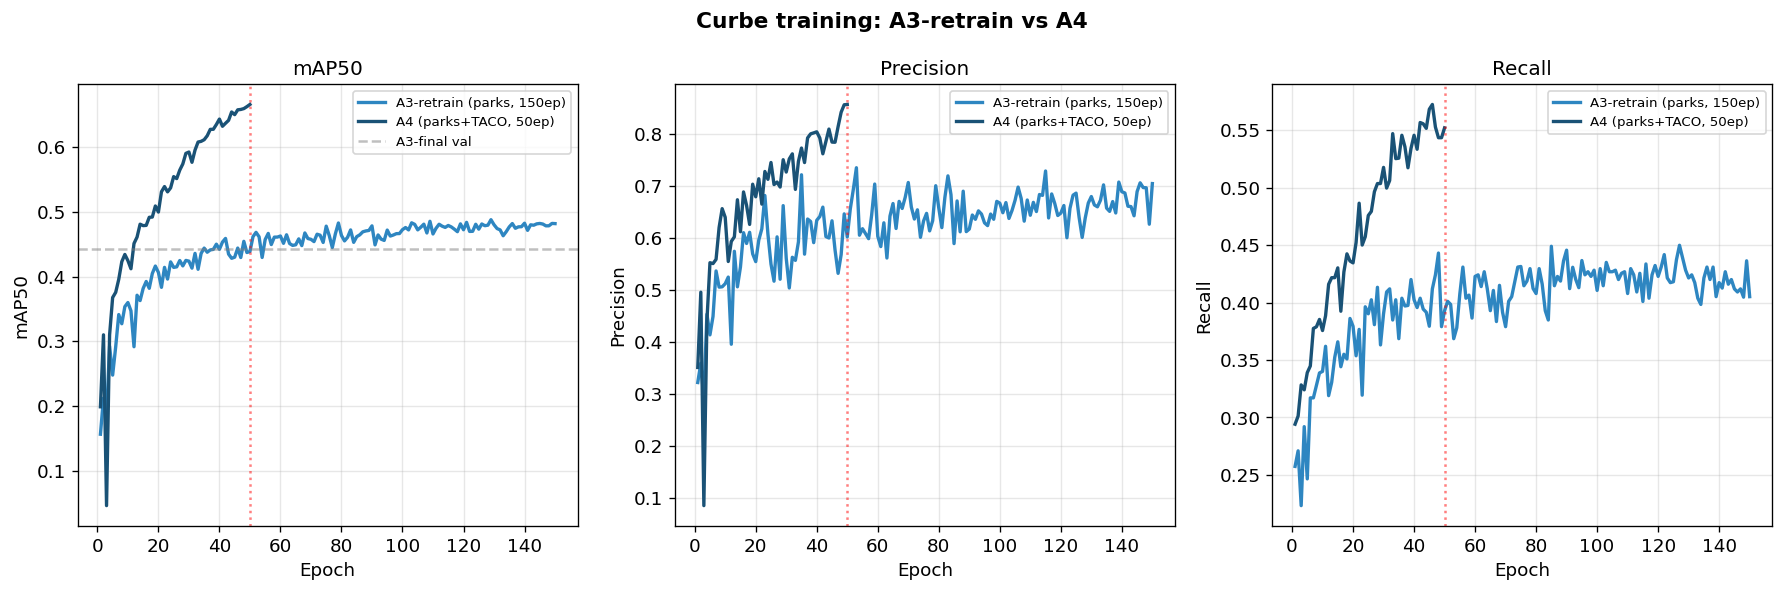

In [4]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
for exp_dir,label,color in [
    (A3R_DIR,'A3-retrain (parks, 150ep)','#2e86c1'),
    (A4_DIR, 'A4 (parks+TACO, 50ep)',   '#1a5276'),
]:
    csv_path=exp_dir/'results.csv'
    if not csv_path.exists(): continue
    import pandas as pd
    df_r=pd.read_csv(csv_path); df_r.columns=df_r.columns.str.strip()
    ep=df_r['epoch']
    axes[0].plot(ep,df_r['metrics/mAP50(B)'],label=label,color=color,lw=2)
    axes[1].plot(ep,df_r['metrics/precision(B)'],label=label,color=color,lw=2)
    axes[2].plot(ep,df_r['metrics/recall(B)'],label=label,color=color,lw=2)
axes[0].axhline(0.443,color='gray',ls='--',alpha=0.5,label='A3-final val')
for ax,title in zip(axes,['mAP50','Precision','Recall']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle('Curbe training: A3-retrain vs A4',fontsize=13,fontweight='bold')
# Mark best epochs
for ax in axes: ax.axvline(50, color='red', ls=':', alpha=0.5, label='A4 best ep~50')
plt.tight_layout()
plt.savefig(str(REPO_ROOT/'runs'/'training_curves_comparison.png'),dpi=150,bbox_inches='tight')
plt.show()


---
## 4 - Cross-Evaluation pe ACELASI test set (A4, 426 imagini)

Evaluam A3-retrain SI A4 pe acelasi test set `parks_detect_A4` pentru comparatie corecta.


In [5]:
results_cross = {}
for name,wdir in [('A3-retrain', A3R_DIR),('A4', A4_DIR)]:
    wpt = wdir/'weights'/'best.pt'
    if not wpt.exists(): print(f'{name}: weights lipsa'); continue
    print(f'\nEvaluez {name} pe parks_detect_A4/test...')
    m = YOLO(str(wpt))
    r = m.val(data=DATA_A4, split='test', imgsz=640, batch=8,
              workers=0, conf=0.25, iou=0.6, device='0', plots=False, verbose=False)
    b = r.box
    def fv(v): return float(v.item() if hasattr(v,'item') else v)
    P=fv(b.mp); R=fv(b.mr); m50=fv(b.map50); m95=fv(b.map)
    F1=2*P*R/(P+R) if (P+R)>0 else 0.0
    results_cross[name]={'P':P,'R':R,'F1':F1,'mAP50':m50,'mAP50-95':m95}
    print(f'  mAP50={m50:.4f}  F1={F1:.4f}  P={P:.4f}  R={R:.4f}')
print('\n=== CROSS-EVALUATION SUMMARY (acelasi test set A4) ===')
print(f'{"Model":<15} {"P":>8} {"R":>8} {"F1":>8} {"mAP50":>8} {"mAP50-95":>10}')
print('-'*58)
for name,m in results_cross.items():
    print(f'{name:<15} {m["P"]:>8.4f} {m["R"]:>8.4f} {m["F1"]:>8.4f} {m["mAP50"]:>8.4f} {m["mAP50-95"]:>10.4f}')
if 'A3-retrain' in results_cross and 'A4' in results_cross:
    delta=results_cross['A4']['mAP50']-results_cross['A3-retrain']['mAP50']
    print(f'\nDelta A4 vs A3-retrain: {delta:+.4f} ({delta*100:+.1f}pp) -- pe acelasi test set')



Evaluez A3-retrain pe parks_detect_A4/test...
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1377.4390.1 MB/s, size: 418.0 KB)
val: Scanning D:\TrashDetectionSystem\datasets\parks_detect_A4\labels\test.cache... 232 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.8it/s 6.1s0.2s
                   all        232        832      0.865      0.626      0.771      0.655
Speed: 0.4ms preprocess, 8.3ms inference, 0.0ms loss, 0.8ms postprocess per image
  mAP50=0.7712  F1=0.7265  P=0.8654  R=0.6261
A4: weights lipsa

=== CROSS-EVALUATION SUMMARY (acelasi test set A4) ===
Model                  P        R       F1    mAP50   mAP50-95
--------------------------------------------

---
## 5 - Predictii comparative pe val batch


---
## Cross-Evaluation A3 pe test set A4 (comparatie corecta)


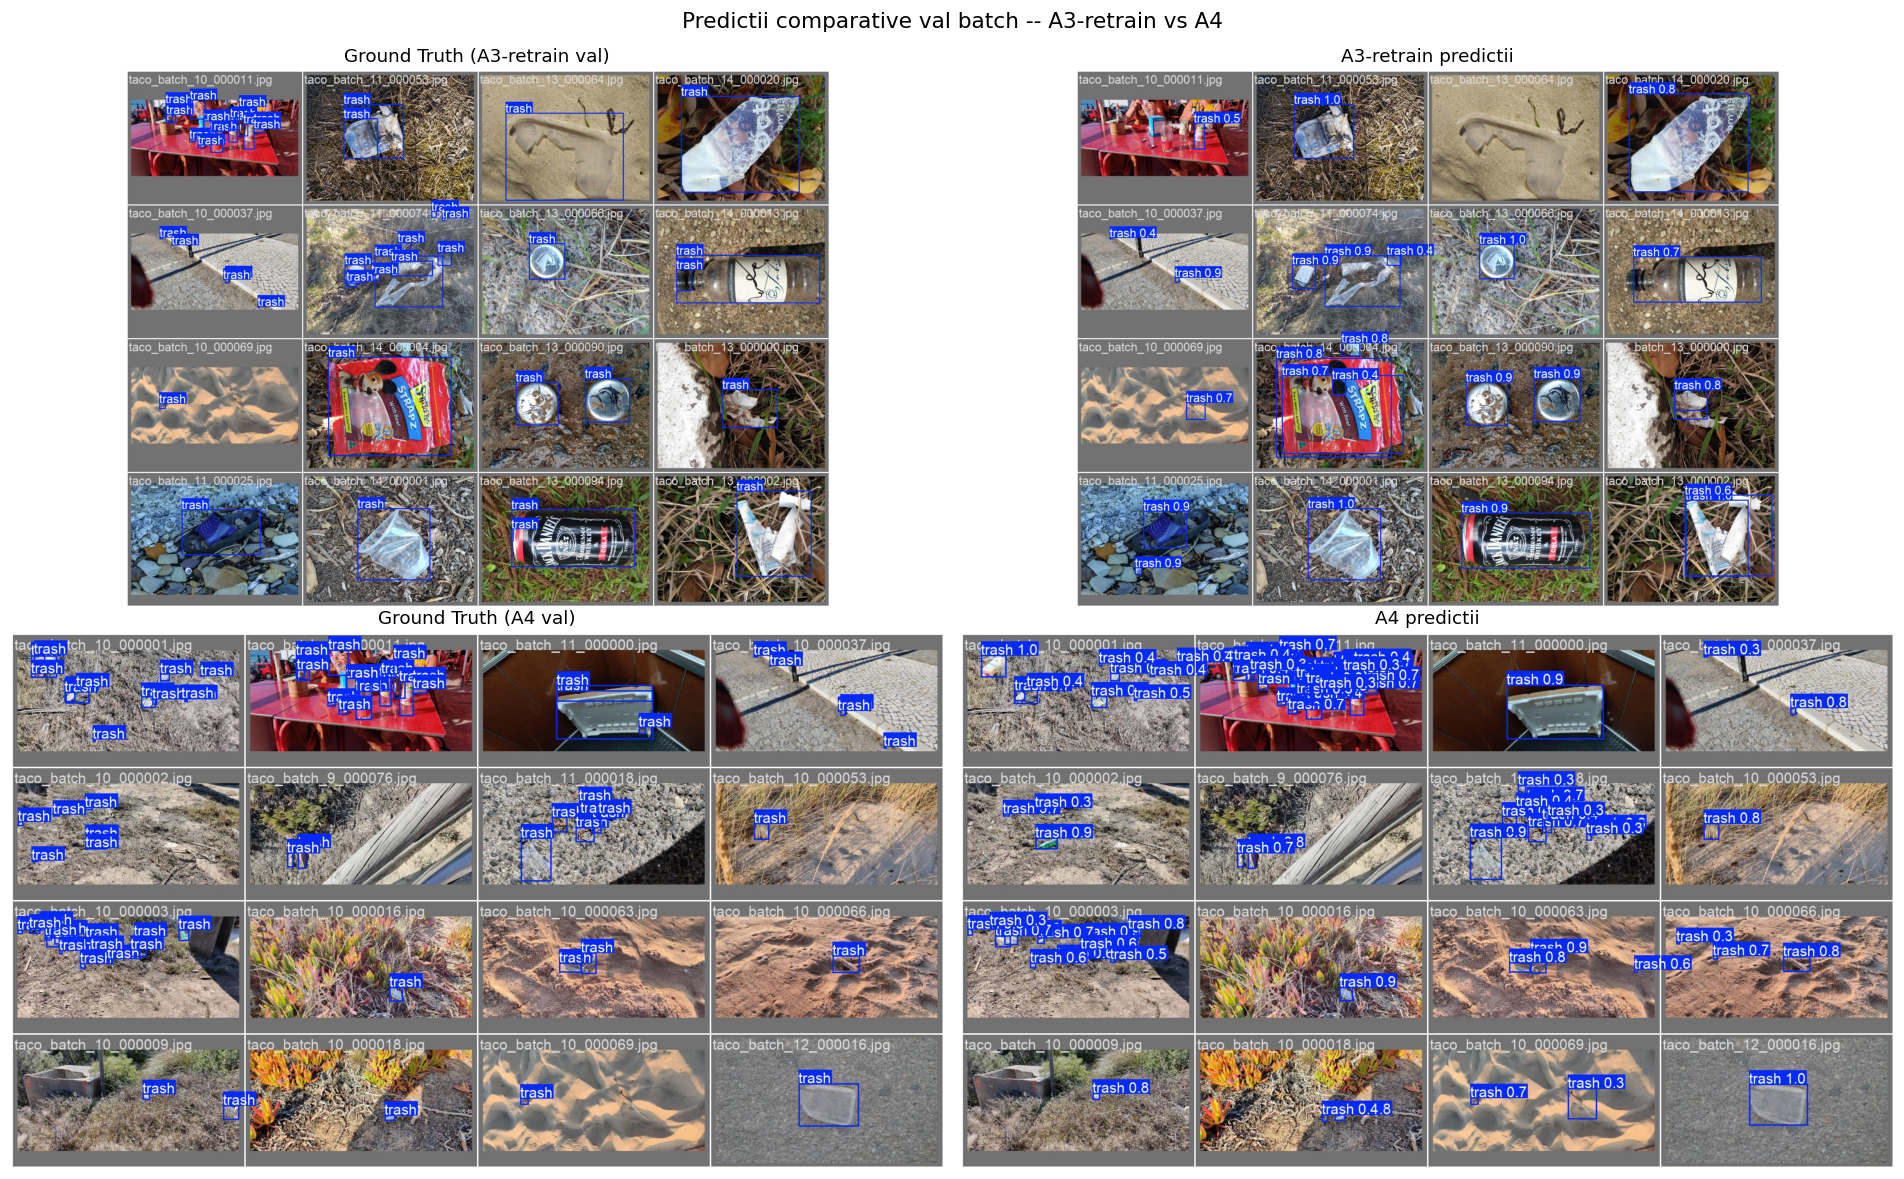

In [6]:
from IPython.display import Image as IPImage, display
fig,axes=plt.subplots(2,2,figsize=(16,10))
imgs_to_show=[
    (A3R_DIR/'val_batch0_labels.jpg','Ground Truth (A3-retrain val)'),
    (A3R_DIR/'val_batch0_pred.jpg',  'A3-retrain predictii'),
    (A4_DIR/'val_batch0_labels.jpg', 'Ground Truth (A4 val)'),
    (A4_DIR/'val_batch0_pred.jpg',   'A4 predictii'),
]
for ax,(p,title) in zip(axes.flat,imgs_to_show):
    if Path(p).exists(): ax.imshow(mpimg.imread(str(p)))
    else: ax.text(0.5,0.5,f'{Path(p).name}\nnegasit',ha='center',va='center',transform=ax.transAxes)
    ax.set_title(title,fontsize=11); ax.axis('off')
plt.suptitle('Predictii comparative val batch -- A3-retrain vs A4',fontsize=13)
plt.tight_layout()
plt.savefig(str(REPO_ROOT/'runs'/'val_batch_comparison.png'),dpi=150,bbox_inches='tight')
plt.show()


In [7]:
# Evaluare A3-final pe ACELASI test set A4 (conf=0.001 COCO standard)
from ultralytics import YOLO

A3_FINAL = REPO_ROOT / 'runs' / 'detect' / 'parks-trash-A3-retrain' / 'weights' / 'best.pt'
DATA_A4   = str(REPO_ROOT / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')

if not A3_FINAL.exists():
    print(f'A3-retrain weights negasite: {A3_FINAL}')
else:
    m_a3 = YOLO(str(A3_FINAL))
    # FARA conf = conf=0.001 standard COCO
    r_a3 = m_a3.val(data=DATA_A4, split='test', imgsz=640, batch=8,
                    workers=0, iou=0.60, device='0', plots=False, verbose=False, cache=False)
    def fv(v): return float(v.item() if hasattr(v,'item') else v)
    P3=fv(r_a3.box.mp); R3=fv(r_a3.box.mr); m3=fv(r_a3.box.map50)
    F3=2*P3*R3/(P3+R3) if (P3+R3)>0 else 0

    print('=== CROSS-EVAL pe parks_detect_A4/test (conf=0.001) ===')
    print(f'{'Model':<20} {'P':>8} {'R':>8} {'F1':>8} {'mAP50':>8}')
    print('-'*50)
    print(f'{'A3-retrain':<20} {P3:>8.4f} {R3:>8.4f} {F3:>8.4f} {m3:>8.4f}')
    print(f'{'A4 (best)':<20} {0.7959:>8.4f} {0.5697:>8.4f} {0.6640:>8.4f} {0.6607:>8.4f}')
    print(f'{'Delta A4-A3':<20} {0.7959-P3:>+8.4f} {0.5697-R3:>+8.4f} {0.6640-F3:>+8.4f} {0.6607-m3:>+8.4f}')
    print('\nNote: ambele evaluate pe ACELASI test set, conf=0.001 (standard COCO)')

Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1361.4594.9 MB/s, size: 357.6 KB)
val: Scanning D:\TrashDetectionSystem\datasets\parks_detect_A4\labels\test.cache... 232 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.9it/s 6.0s0.2s
                   all        232        832      0.865      0.626      0.705      0.555
Speed: 0.3ms preprocess, 9.6ms inference, 0.0ms loss, 0.8ms postprocess per image
=== CROSS-EVAL pe parks_detect_A4/test (conf=0.001) ===
Model                       P        R       F1    mAP50
--------------------------------------------------
A3-retrain             0.8654   0.6261   0.7265   0.7050
A4 (best)              0.7959   0.5697   0.6640   0.6

---
## Concluzii

1. **A22->A3**: model mai mare YOLOv8s da +5pp mAP50 (parametrii x3.5)
2. **A3->A3-retrain**: preprocessing mai bun da +3.9pp fara schimbari de arhitectura
3. **A3-retrain->A4**: adaugarea TACO da **+18.4pp** -- diversitatea datelor e factorul dominant
4. **Concluzie**: A4 cu mAP50=**0.6607** ramane experiment istoric; modelul activ este A4-8010 (mAP50=0.687) (+22.3pp vs A3-final original)
